# 03 · 自注意力 Self-Attention

bigram 笨在「只看前一個字」。**自注意力**讓每個位置能**回頭看前面所有字**，並自己決定「該注意誰」。這是 Transformer 的心臟，也是整個 LLM 革命的引擎。這堂課從零把單頭注意力刻出來。

## 學習目標

- 理解自注意力要解決什麼：讓 token 之間互相「溝通」
- 親手實作 **Query / Key / Value** 與縮放點積注意力
- 理解**因果遮罩**：預測時不能偷看未來

## 1. 直覺：Q / K / V

每個 token 產生三個向量：

- **Query（查詢）**：我想找什麼樣的資訊？
- **Key（鍵）**：我有什麼樣的資訊？
- **Value（值）**：如果你需要我，我給你這個內容。

每個位置用自己的 Query 去和**所有位置的 Key** 比對（點積），算出「該多注意誰」的權重，再用權重把大家的 Value 加權平均起來。這樣每個 token 就「吸收」了它該關注的上下文。

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(0)
B, T, C = 1, 6, 16        # 1 句、6 個 token、每個 16 維
head_size = 16
x = torch.randn(B, T, C)  # 假裝這是 6 個 token 的嵌入

key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

q, k, v = query(x), key(x), value(x)
att = q @ k.transpose(-2, -1) * head_size ** -0.5   # 縮放點積：每個位置對每個位置的分數
print("注意力分數矩陣形狀:", att.shape, "(每個 token 對每個 token)")

注意力分數矩陣形狀: torch.Size([1, 6, 6]) (每個 token 對每個 token)


## 2. 因果遮罩：不能偷看未來

預測第 3 個字時，模型只能看第 1、2、3 個字——**絕不能看到後面的答案**。我們用一個下三角遮罩，把「未來」的分數設成 `-inf`，softmax 後就變成 0。

In [2]:
tril = torch.tril(torch.ones(T, T))
att = att.masked_fill(tril == 0, float("-inf"))   # 未來位置設成 -inf
att = F.softmax(att, dim=-1)                       # 每一列加總為 1
out = att @ v                                       # 用權重加權平均 Value

print("注意力權重（每列總和=1，右上角為0=看不到未來）:")
print(att[0].detach().round(decimals=2))
print("\n輸出形狀:", out.shape)

注意力權重（每列總和=1，右上角為0=看不到未來）:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5400, 0.4600, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3400, 0.3100, 0.3600, 0.0000, 0.0000, 0.0000],
        [0.0900, 0.1100, 0.1500, 0.6400, 0.0000, 0.0000],
        [0.1700, 0.1700, 0.3100, 0.1600, 0.2000, 0.0000],
        [0.0800, 0.1300, 0.0700, 0.4400, 0.1700, 0.1100]])

輸出形狀: torch.Size([1, 6, 16])


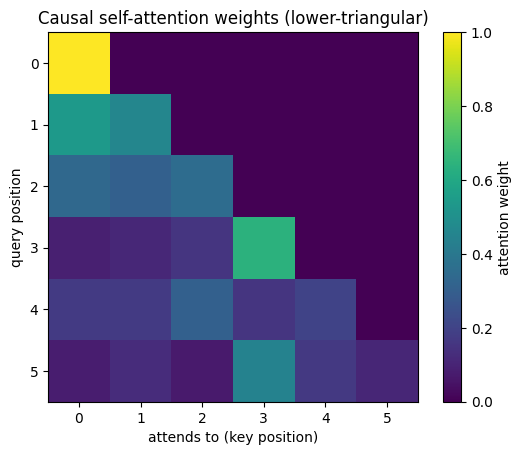

In [3]:
import matplotlib.pyplot as plt

plt.imshow(att[0].detach(), cmap="viridis")
plt.colorbar(label="attention weight")
plt.xlabel("attends to (key position)"); plt.ylabel("query position")
plt.title("Causal self-attention weights (lower-triangular)")
plt.show()

看那張圖：左下三角有值、右上三角全 0——每個位置只能注意自己與前面的位置。這就是 GPT 能「邊讀邊預測、又不作弊」的關鍵。

## 小結

- 自注意力讓每個 token 回頭看前文，自己決定該注意誰。
- **Q·K** 算注意力分數 →（縮放）→ 遮罩 → softmax → 加權 **V**。
- **因果遮罩**確保預測時看不到未來的字。

## 練習

1. 把 `head_size` 的縮放 `** -0.5` 拿掉，softmax 後的權重會變得多極端？（這就是為什麼要「縮放」點積）
2. 把因果遮罩拿掉，觀察權重矩陣變成完整方陣——這適合翻譯，但不適合「預測下一個字」。

下一課，把多個注意力頭和前饋層**組裝成完整的 Transformer**。